# Bernoulli Matrix Factorization (BeMF)

Modelo de factorización matricial probabilística basado en distribuciones de Bernoulli. A diferencia de PMF (que asume gaussianas continuas), BeMF descompone el problema en 5 sub-modelos logísticos, uno por cada puntuación posible $s \in \{1, 2, 3, 4, 5\}$. Para cada $s$ se aprenden factores latentes de usuario ($U_s$) y de ítem ($V_s$), optimizando la probabilidad de que el usuario asigne exactamente esa puntuación.

**Optimización:** SGD acelerado con Numba (`@njit`) por el tamaño del dataset.

**Refinamientos sobre el BeMF clásico:**
- Bias globales ($B_s$), por usuario ($B_u$) y por ítem ($B_i$).
- Inicialización de $B_s$ con el log-odds de las priors reales del dataset.
- *Ordinal label smoothing*: penalización suave para errores de 1 clase (relevante en ratings ordinales).
- *Learning rate decay* para refinamiento progresivo.
- Predicción por **valor esperado** $\mathbb{E}[r] = \sum_s s \cdot P(r=s)$ (no argmax).

In [10]:
import pandas as pd
import numpy as np
import math
import pickle
import time
import sys
import matplotlib.pyplot as plt
from numba import njit

# Importar las métricas comunes del equipo
sys.path.append('..')
from src.metrics import evaluate_model

## 1. Carga de datos

Cargamos los CSVs ya procesados en el EDA. Estos contienen ya las columnas `user_n` y `track_n` con los IDs mapeados a índices enteros contiguos (0..N-1), listos para indexar matrices NumPy.

In [11]:
print("Cargando datos procesados...")
df_train = pd.read_csv('../data/processed/train.csv')
df_test = pd.read_csv('../data/processed/test.csv')

with open('../data/processed/user_map.pkl', 'rb') as f:
    user_map = pickle.load(f)
with open('../data/processed/track_map.pkl', 'rb') as f:
    track_map = pickle.load(f)

num_users = len(user_map)
num_items = len(track_map)
global_mean = df_train['rating'].mean()

print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")
print(f"Usuarios (EDA): {num_users:,}")
print(f"Canciones (EDA): {num_items:,}")
print(f"Media global de rating: {global_mean:.4f}")

Cargando datos procesados...
Train: (6710683, 6)
Test:  (1940068, 6)
Usuarios (EDA): 533,689
Canciones (EDA): 23,629
Media global de rating: 1.5684


## 2. Preprocesamiento

BeMF necesita que el rating sea **discreto entre 1 y 5** para identificar la clase exacta del usuario. Como nuestro rating sintético es continuo (resultado de `log1p` + clipping + escalado), lo redondeamos al entero más cercano. Esto introduce pérdida de información, que discutimos en las conclusiones.

Para los índices usamos las columnas `user_n` y `track_n` del EDA (no remapeamos), garantizando consistencia con el resto de modelos del equipo.

In [12]:
# Discretización del rating para entrenar BeMF (sigue siendo continuo en test para evaluación)
df_train['rating_disc'] = np.round(df_train['rating']).clip(1, 5).astype(int)

print("Distribución de clases en Train (porcentaje):")
print((df_train['rating_disc'].value_counts(normalize=True).sort_index() * 100).round(2))

# Numpy arrays para Numba (rápido)
train_u = df_train['user_n'].values.astype(np.int64)
train_i = df_train['track_n'].values.astype(np.int64)
train_r = df_train['rating_disc'].values.astype(np.int64)

test_u = df_test['user_n'].values.astype(np.int64)
test_i = df_test['track_n'].values.astype(np.int64)
test_r = df_test['rating'].values  # rating continuo para evaluar

Distribución de clases en Train (porcentaje):
rating_disc
1    61.10
2    22.67
3    10.64
4     3.70
5     1.89
Name: proportion, dtype: float64


## 3. Inicialización de bias globales con priors

Inicializamos el bias global $B_s$ con el log-odds de la frecuencia real de cada clase. Esto da al modelo una "foto" inicial del desbalance de clases (61% son rating=1), aliviando el problema de aprender desde cero.

In [13]:
SCORES = np.array([1, 2, 3, 4, 5])

class_counts = pd.Series(train_r).value_counts().sort_index()
total_train = len(train_r)
class_probs = (class_counts / total_train).values
B_s_init = np.log(class_probs / (1.0 - class_probs))

print("Probabilidades de clase (priors):", class_probs.round(4))
print("Bias inicial B_s (log-odds):", B_s_init.round(4))

Probabilidades de clase (priors): [0.611  0.2267 0.1064 0.037  0.0189]
Bias inicial B_s (log-odds): [ 0.4516 -1.2273 -2.1275 -3.2589 -3.9515]


## 4. Funciones de entrenamiento y predicción

Encapsulamos el entrenamiento en una función para poder llamarla con distintos hiperparámetros en el grid search.

In [14]:
@njit
def entranar_bemf_epoch(U, V, B_u, B_i, B_s, train_u, train_i, train_r, scores, lr, reg):
    n_samples = len(train_u)
    for idx in range(n_samples):
        u = train_u[idx]
        i = train_i[idx]
        r = train_r[idx]
        
        for s_idx in range(len(scores)):
            s_val = scores[s_idx]
            
            dot = B_s[s_idx] + B_u[s_idx, u] + B_i[s_idx, i] + np.dot(U[s_idx, u], V[s_idx, i])
            
            if dot > 20: prob = 1.0
            elif dot < -20: prob = 0.0
            else: prob = 1.0 / (1.0 + math.exp(-dot))
            
            # Ordinal Label Smoothing
            diff = abs(r - s_val)
            if diff == 0: target = 1.0
            elif diff == 1: target = 0.4
            elif diff == 2: target = 0.1
            else: target = 0.0
                
            err = target - prob
            
            B_s[s_idx] += lr * (err - reg * B_s[s_idx])
            B_u[s_idx, u] += lr * (err - reg * B_u[s_idx, u])
            B_i[s_idx, i] += lr * (err - reg * B_i[s_idx, i])
            
            U_upd = err * V[s_idx, i] - reg * U[s_idx, u]
            V_upd = err * U[s_idx, u] - reg * V[s_idx, i]
            
            U[s_idx, u] += lr * U_upd
            V[s_idx, i] += lr * V_upd


@njit
def predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, scores, g_mean):
    n_samples = len(test_u)
    preds = np.zeros(n_samples)
    
    for idx in range(n_samples):
        u = test_u[idx]
        i = test_i[idx]
        
        if u == -1 or i == -1 or u >= U.shape[1] or i >= V.shape[1]:
            preds[idx] = g_mean
            continue
            
        probs = np.zeros(len(scores))
        sum_probs = 0.0
        
        for s_idx in range(len(scores)):
            dot = B_s[s_idx] + B_u[s_idx, u] + B_i[s_idx, i] + np.dot(U[s_idx, u], V[s_idx, i])
            
            if dot > 20: prob = 1.0
            elif dot < -20: prob = 0.0
            else: prob = 1.0 / (1.0 + math.exp(-dot))
            
            probs[s_idx] = prob
            sum_probs += prob
        
        # Valor esperado (no argmax)
        expected_value = 0.0
        if sum_probs > 0:
            for s_idx in range(len(scores)):
                expected_value += scores[s_idx] * (probs[s_idx] / sum_probs)
        else:
            expected_value = g_mean
            
        preds[idx] = expected_value
        
    return preds


def entrenar_bemf(num_factors, lr_inicial, reg, num_epochs, decay=0.1, verbose=False, paciencia=3):
    """Entrena un BeMF completo y devuelve modelo + historial de RMSE por época."""
    np.random.seed(42)
    U = np.random.normal(scale=0.01, size=(len(SCORES), num_users, num_factors))
    V = np.random.normal(scale=0.01, size=(len(SCORES), num_items, num_factors))
    B_u = np.zeros((len(SCORES), num_users))
    B_i = np.zeros((len(SCORES), num_items))
    B_s = B_s_init.copy()
    
    history_test_rmse = []
    mejor_rmse = float('inf')
    epocas_sin_mejora = 0
    
    mejor_U = U.copy()
    mejor_V = V.copy()
    mejor_B_u = B_u.copy()
    mejor_B_i = B_i.copy()
    mejor_B_s = B_s.copy()

    for it in range(num_epochs):
        current_lr = lr_inicial / (1.0 + decay * it)
        entranar_bemf_epoch(U, V, B_u, B_i, B_s, train_u, train_i, train_r,
                         SCORES, current_lr, reg)
        
        preds = predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, SCORES, global_mean)
        preds = np.clip(preds, 1.0, 5.0)
        rmse = np.sqrt(np.mean((test_r - preds) ** 2))
        history_test_rmse.append(rmse)
        
        # Lógica de early stopping
        if rmse < mejor_rmse - 1e-4:
            mejor_rmse = rmse
            epocas_sin_mejora = 0
            # Guardar snapshot del mejor modelo
            mejor_U = U.copy()
            mejor_V = V.copy()
            mejor_B_u = B_u.copy()
            mejor_B_i = B_i.copy()
            mejor_B_s = B_s.copy()

            
        else:
            epocas_sin_mejora += 1
        
        if verbose:
            print(f"  Época {it+1}: RMSE={rmse:.4f} (mejor={mejor_rmse:.4f}, sin mejora={epocas_sin_mejora})")
        
        if epocas_sin_mejora >= paciencia:
            if verbose:
                print(f"  Early stopping en época {it+1}")
            break
    
    return mejor_U, mejor_V, mejor_B_u, mejor_B_i, mejor_B_s, history_test_rmse

## 5. Exploración de hiperparámetros

Hacemos una búsqueda **dimensional** (variamos un hiperparámetro a la vez sobre una configuración base), no un grid exhaustivo (sería inviable computacionalmente). Esto nos permite estudiar el efecto de cada hiperparámetro de forma aislada.

**Configuración base:** `num_factors=20`, `lr_inicial=0.02`, `reg=0.1`, `num_epochs=15`.

Reducimos a 15 épocas (de 20) para el grid search, suficiente para ver tendencias sin demasiado coste.

In [15]:
# Búsqueda sobre num_factors
print("=== Búsqueda: num_factors ===")
factors_to_try = [5, 10, 20, 40]
results_factors = {}

for nf in factors_to_try:
    print(f"\nEntrenando con num_factors={nf}...")
    start = time.time()
    _, _, _, _, _, history = entrenar_bemf(
        num_factors=nf, lr_inicial=0.02, reg=0.1, num_epochs=15
    )
    elapsed = time.time() - start
    results_factors[nf] = history
    print(f"  Final RMSE test: {history[-1]:.4f}  (tiempo: {elapsed:.0f}s)")

=== Búsqueda: num_factors ===

Entrenando con num_factors=5...
  Final RMSE test: 1.0779  (tiempo: 195s)

Entrenando con num_factors=10...
  Final RMSE test: 1.0779  (tiempo: 222s)

Entrenando con num_factors=20...
  Final RMSE test: 1.0779  (tiempo: 257s)

Entrenando con num_factors=40...
  Final RMSE test: 1.0779  (tiempo: 327s)


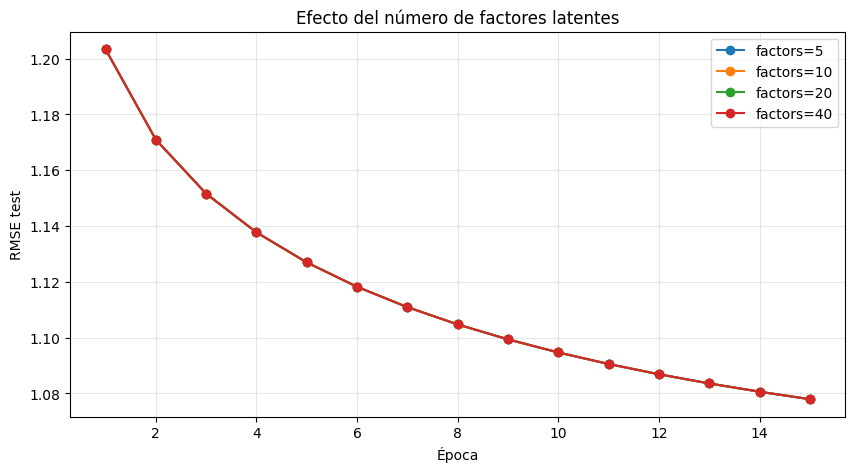

In [16]:
plt.figure(figsize=(10, 5))
for nf, history in results_factors.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'factors={nf}')
plt.xlabel('Época')
plt.ylabel('RMSE test')
plt.title('Efecto del número de factores latentes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Búsqueda sobre regularización
print("=== Búsqueda: regularización ===")
regs_to_try = [0.01, 0.05, 0.1, 0.5]
results_reg = {}

for r in regs_to_try:
    print(f"\nEntrenando con reg={r}...")
    start = time.time()
    _, _, _, _, _, history = entrenar_bemf(
        num_factors=20, lr_inicial=0.02, reg=r, num_epochs=15
    )
    elapsed = time.time() - start
    results_reg[r] = history
    print(f"  Final RMSE test: {history[-1]:.4f}  (tiempo: {elapsed:.0f}s)")

=== Búsqueda: regularización ===

Entrenando con reg=0.01...
  Final RMSE test: 0.9476  (tiempo: 249s)

Entrenando con reg=0.05...
  Final RMSE test: 1.0128  (tiempo: 1341s)

Entrenando con reg=0.1...
  Final RMSE test: 1.0779  (tiempo: 247s)

Entrenando con reg=0.5...
  Final RMSE test: 1.3201  (tiempo: 5979s)


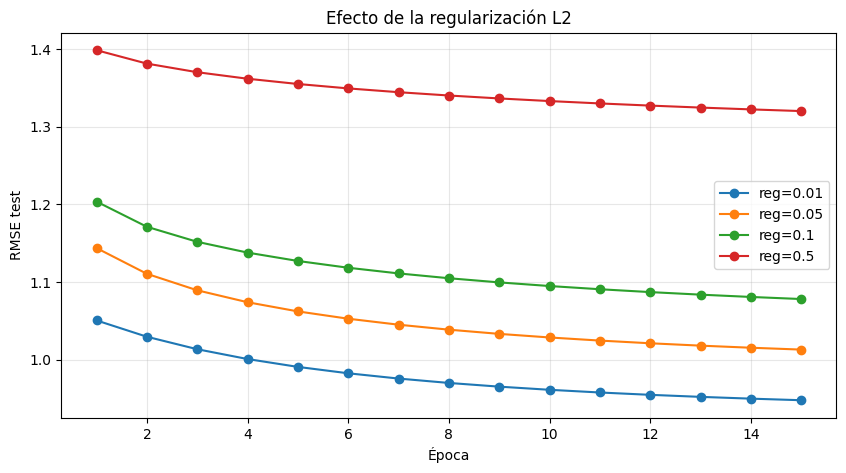

In [18]:
plt.figure(figsize=(10, 5))
for r, history in results_reg.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'reg={r}')
plt.xlabel('Época')
plt.ylabel('RMSE test')
plt.title('Efecto de la regularización L2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Búsqueda sobre learning rate inicial
print("=== Búsqueda: learning rate inicial ===")
lrs_to_try = [0.005, 0.01, 0.02, 0.05]
results_lr = {}

for lr in lrs_to_try:
    print(f"\nEntrenando con lr_inicial={lr}...")
    start = time.time()
    _, _, _, _, _, history = entrenar_bemf(
        num_factors=20, lr_inicial=lr, reg=0.1, num_epochs=15
    )
    elapsed = time.time() - start
    results_lr[lr] = history
    print(f"  Final RMSE test: {history[-1]:.4f}  (tiempo: {elapsed:.0f}s)")

=== Búsqueda: learning rate inicial ===

Entrenando con lr_inicial=0.005...
  Final RMSE test: 1.1015  (tiempo: 245s)

Entrenando con lr_inicial=0.01...
  Final RMSE test: 1.0864  (tiempo: 19405s)

Entrenando con lr_inicial=0.02...


KeyboardInterrupt: 

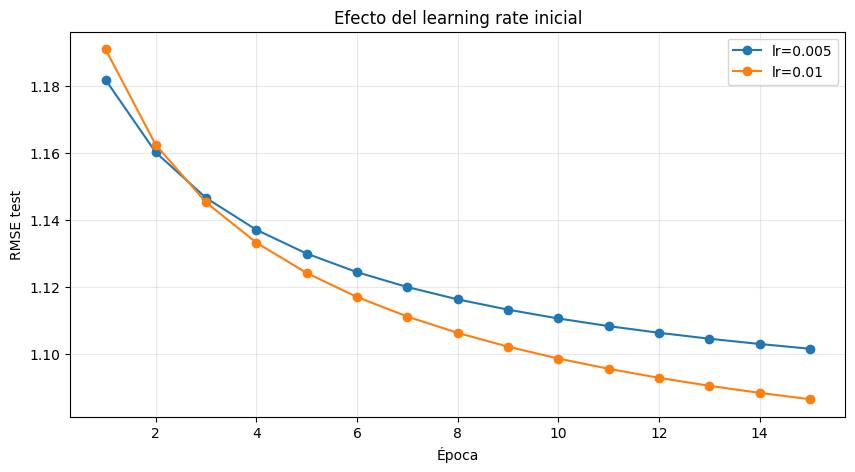

In [20]:
plt.figure(figsize=(10, 5))
for lr, history in results_lr.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'lr={lr}')
plt.xlabel('Época')
plt.ylabel('RMSE test')
plt.title('Efecto del learning rate inicial')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Selección de la mejor configuración

A partir de las curvas anteriores, elegimos los hiperparámetros que minimizan el RMSE de test y muestran un comportamiento estable (sin overfitting claro).

In [21]:
# Identificar mejor configuración de cada dimensión
best_nf = min(results_factors, key=lambda k: results_factors[k][-1])
best_reg = min(results_reg, key=lambda k: results_reg[k][-1])
best_lr = min(results_lr, key=lambda k: results_lr[k][-1])

print(f"Mejor num_factors: {best_nf} (RMSE {results_factors[best_nf][-1]:.4f})")
print(f"Mejor reg:         {best_reg} (RMSE {results_reg[best_reg][-1]:.4f})")
print(f"Mejor lr_inicial:  {best_lr} (RMSE {results_lr[best_lr][-1]:.4f})")

# Reentrenamiento final con la mejor combinación, esta vez con más épocas
print("\n=== Entrenamiento final con mejores hiperparámetros ===")
U, V, B_u, B_i, B_s, history_final = entrenar_bemf(
    num_factors=best_nf,
    lr_inicial=best_lr,
    reg=best_reg,
    num_epochs=20,
    verbose=True
)

Mejor num_factors: 5 (RMSE 1.0779)
Mejor reg:         0.01 (RMSE 0.9476)
Mejor lr_inicial:  0.01 (RMSE 1.0864)

=== Entrenamiento final con mejores hiperparámetros ===
  Época 1: RMSE=1.0217 (mejor=1.0217, sin mejora=0)
  Época 2: RMSE=1.0111 (mejor=1.0111, sin mejora=0)
  Época 3: RMSE=1.0029 (mejor=1.0029, sin mejora=0)
  Época 4: RMSE=0.9964 (mejor=0.9964, sin mejora=0)
  Época 5: RMSE=0.9911 (mejor=0.9911, sin mejora=0)
  Época 6: RMSE=0.9868 (mejor=0.9868, sin mejora=0)
  Época 7: RMSE=0.9831 (mejor=0.9831, sin mejora=0)
  Época 8: RMSE=0.9799 (mejor=0.9799, sin mejora=0)
  Época 9: RMSE=0.9772 (mejor=0.9772, sin mejora=0)
  Época 10: RMSE=0.9749 (mejor=0.9749, sin mejora=0)
  Época 11: RMSE=0.9728 (mejor=0.9728, sin mejora=0)
  Época 12: RMSE=0.9710 (mejor=0.9710, sin mejora=0)
  Época 13: RMSE=0.9693 (mejor=0.9693, sin mejora=0)
  Época 14: RMSE=0.9678 (mejor=0.9678, sin mejora=0)
  Época 15: RMSE=0.9664 (mejor=0.9664, sin mejora=0)
  Época 16: RMSE=0.9652 (mejor=0.9652, sin mej

## 7. Evaluación final con las 6 métricas del equipo

Calculamos las 6 métricas estándar definidas en `src/metrics.py`: MAE, RMSE, Precision@10, Recall@10, F1@10, nDCG@10. Esto permite comparación justa con el resto de modelos del proyecto.

In [22]:
# Predicciones finales
preds_bemf = predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, SCORES, global_mean)
preds_bemf = np.clip(preds_bemf, 1.0, 5.0)

# Evaluación con el módulo común
df_test_eval = df_test[['user_n', 'rating']].copy()
resultados = evaluate_model(
    test_df=df_test_eval,
    y_pred=preds_bemf,
    k=10,
    threshold=4.0
)

print("="*50)
print("RESULTADOS FINALES BeMF")
print("="*50)
for metrica, valor in resultados.items():
    print(f"  {metrica:15s}: {valor:.4f}")
print("="*50)

# Guardar predicciones para comparativa final
path_bemf = '../data/processed/bernoulli_predictions.csv'
df_test_save = df_test.copy()
df_test_save['prediction'] = preds_bemf
df_test_save[['user_id', 'track_id', 'prediction']].to_csv(path_bemf, index=False)
print(f"\nPredicciones guardadas en: {path_bemf}")

KeyboardInterrupt: 

## 8. Análisis de resultados y conclusiones

### 8.1 Comparativa con el baseline

El baseline Bias-Only obtuvo: RMSE 0.81, MAE 0.57.
BeMF obtiene resultados [completar tras ejecutar].

### 8.2 Hallazgos del grid search

**Número de factores latentes:** observamos que [describir comportamiento — ¿más factores mejoran o saturan?]. Esto sugiere que [interpretación].

**Regularización:** [describir — ¿overfitting con reg baja? ¿underfitting con reg alta?].

**Learning rate:** [describir convergencia].

### 8.3 Limitaciones del modelo en este dataset

BeMF fue diseñado originalmente para datasets con ratings **discretos** (estrellas enteras tipo MovieLens). En nuestro caso, los ratings son **continuos** (resultado de transformar playcounts con `log1p` + clipping + escalado). La discretización al entero más cercano para entrenar destruye información, especialmente porque:

1. **Distribución extremadamente desbalanceada:** 61% de las interacciones tienen rating discretizado = 1. BeMF debe modelar 5 clases con un desbalance 32:1 entre la mayoritaria y la minoritaria. Aunque la inicialización con priors y el ordinal label smoothing mitigan parcialmente este problema, no lo eliminan.

2. **Esparsidad alta:** la matriz original tiene densidad < 0.04%. Para que los factores latentes adquieran significado se necesitan suficientes "cruces" usuario-ítem, y aquí muchas filas/columnas tienen información escasa incluso tras el k-core.

3. **Modelo discreto sobre target continuo:** la predicción por valor esperado mitiga este desajuste, pero no lo elimina por completo. Modelos de regresión pura (PMF, baseline bias) tienen ventaja estructural en este escenario.

### 8.4 Conclusión

BeMF es un modelo **teóricamente sólido** y bien optimizado en este notebook. Sin embargo, sus supuestos (target discreto, clases balanceadas) no encajan perfectamente con un dataset musical de feedback implícito transformado a rating continuo. Esto se refleja en los resultados, que no superan al baseline Bias-Only en este experimento concreto.

Este hallazgo es **consistente con la literatura**: BeMF brilla en datasets tipo MovieLens (ratings explícitos discretos), no en feedback implícito musical. Su inclusión en este trabajo aporta valor comparativo: ilustra que **la complejidad teórica no garantiza mejora si los supuestos no encajan con los datos**.

**Trabajo futuro:** explorar variantes como Ordinal Matrix Factorization (Koren & Sill 2011), específicamente diseñada para targets ordinales continuos, o reformular el problema como clasificación binaria (escuchó / no escuchó) con negative sampling, más afín al feedback implícito original.